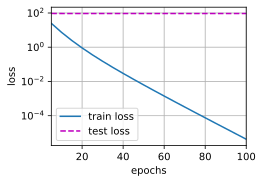

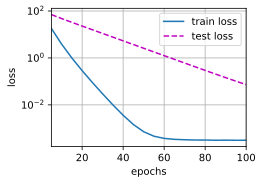

In [1]:
import torch
from torch import nn
from d2l import torch as d2l

# 1. 生成数据（与 4.5.2 完全一致）
n_train, n_test, num_inputs, batch_size = 20, 100, 200, 5
true_w, true_b = torch.ones((num_inputs, 1)) * 0.01, 0.05

train_data = d2l.synthetic_data(true_w, true_b, n_train)
train_iter = d2l.load_array(train_data, batch_size)

test_data = d2l.synthetic_data(true_w, true_b, n_test)
test_iter = d2l.load_array(test_data, batch_size, is_train=False)

# 2. 初始化参数（与书中一致）
def init_params():
    w = torch.normal(0, 1, size=(num_inputs, 1), requires_grad=True)
    b = torch.zeros(1, requires_grad=True)
    return [w, b]

# 3. L2 范数惩罚项（完全相同）
def l2_penalty(w):
    return torch.sum(w.pow(2)) / 2

# 4. 训练函数（与书中保持 100% 相同结构）
def train(lambd):
    w, b = init_params()
    net = lambda X: d2l.linreg(X, w, b)
    loss = d2l.squared_loss
    num_epochs, lr = 100, 0.003
    animator = d2l.Animator(xlabel='epochs', ylabel='loss', yscale='log',
                            xlim=[5, num_epochs], legend=['train loss', 'test loss'])

    for epoch in range(num_epochs):
        for X, y in train_iter:
            # 增加正则项（关键部分）
            l = loss(net(X), y) + lambd * l2_penalty(w)
            l.sum().backward()
            d2l.sgd([w, b], lr, batch_size)  # 参数更新
        if (epoch + 1) % 5 == 0:
            animator.add(epoch + 1, (d2l.evaluate_loss(net, train_iter, loss),
                                     d2l.evaluate_loss(net, test_iter, loss)))
    print("最终 w L2 范数：", torch.norm(w).item())

# 5. 测试：不加正则
print("------ λ = 0（无权重衰减）------")
train(lambd=0)

# 6. 测试：加权重衰减
print("------ λ = 3（使用权重衰减）------")
train(lambd=3)
